# Statistical Foundations I: Stationarity Analysis

**Day 5 Task**: Test stationarity of FX prices vs returns

**Key Questions:**
1. Are FX prices stationary? (Expected: No - unit root present)
2. Are FX returns stationary? (Expected: Yes - can be traded)
3. What are the implications for strategy development?

**Tests Used:**
- **ADF (Augmented Dickey-Fuller)**: H0 = unit root (non-stationary)
- **KPSS**: H0 = stationary

**Interpretation:**
- ADF p-value < 0.05 → Reject H0 → Stationary
- KPSS p-value > 0.05 → Accept H0 → Stationary

In [1]:
# Setup
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load FX data
data_dir = project_root / 'data' / 'raw'
pairs = ['EURUSD60', 'GBPUSD60', 'USDJPY60']

data = {}
for pair in pairs:
    filepath = data_dir / f'{pair}.csv'
    if filepath.exists():
        df = pd.read_csv(
            filepath,
            header=None,
            names=['date', 'time', 'open', 'high', 'low', 'close', 'volume']
        )
        
        # Parse datetime from date + time columns
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], utc=True)
        df.set_index('datetime', inplace=True)
        df.drop(columns=['date', 'time'], inplace=True)
        
        data[pair.replace('60', '')] = df
        print(f'✅ {pair}: {len(df):,} bars, columns: {list(df.columns)}')

print(f'\nLoaded {len(data)} FX pairs')

✅ EURUSD60: 2,048 bars, columns: ['open', 'high', 'low', 'close', 'volume']
✅ GBPUSD60: 65,000 bars, columns: ['open', 'high', 'low', 'close', 'volume']
✅ USDJPY60: 2,049 bars, columns: ['open', 'high', 'low', 'close', 'volume']

Loaded 3 FX pairs


## Stationarity Test Function

In [3]:
def test_stationarity(series, name='Series'):
    """
    Run ADF and KPSS tests on a time series.
    
    Returns:
        dict with test results and interpretation
    """
    series_clean = series.dropna()
    
    # ADF Test (H0: unit root / non-stationary)
    adf_result = adfuller(series_clean, autolag='AIC')
    adf_stat, adf_pvalue = adf_result[0], adf_result[1]
    adf_reject = adf_pvalue < 0.05
    
    # KPSS Test (H0: stationary)
    kpss_result = kpss(series_clean, regression='c', nlags='auto')
    kpss_stat, kpss_pvalue = kpss_result[0], kpss_result[1]
    kpss_accept = kpss_pvalue > 0.05
    
    # Overall conclusion
    is_stationary = adf_reject and kpss_accept
    
    return {
        'name': name,
        'adf_stat': adf_stat,
        'adf_pvalue': adf_pvalue,
        'adf_stationary': adf_reject,
        'kpss_stat': kpss_stat,
        'kpss_pvalue': kpss_pvalue,
        'kpss_stationary': kpss_accept,
        'is_stationary': is_stationary
    }

def print_stationarity_results(result):
    """Pretty print stationarity test results."""
    print(f"\n{'='*60}")
    print(f"Stationarity Test: {result['name']}")
    print(f"{'='*60}")
    print(f"\nADF Test (H0: Non-Stationary):")
    print(f"  Statistic: {result['adf_stat']:.4f}")
    print(f"  p-value: {result['adf_pvalue']:.4f}")
    print(f"  Result: {'✅ STATIONARY (reject H0)' if result['adf_stationary'] else '❌ NON-STATIONARY (fail to reject H0)'}")
    
    print(f"\nKPSS Test (H0: Stationary):")
    print(f"  Statistic: {result['kpss_stat']:.4f}")
    print(f"  p-value: {result['kpss_pvalue']:.4f}")
    print(f"  Result: {'✅ STATIONARY (accept H0)' if result['kpss_stationary'] else '❌ NON-STATIONARY (reject H0)'}")
    
    print(f"\nFinal Conclusion:")
    if result['is_stationary']:
        print(f"  ✅ Series is STATIONARY (both tests agree)")
        print(f"  → Suitable for statistical modeling")
    else:
        print(f"  ❌ Series is NON-STATIONARY")
        print(f"  → Must use returns or differencing")
    print(f"{'='*60}")

## Test 1: Price Levels (Expected: Non-Stationary)

In [4]:
# Test prices for each pair
price_results = {}

for pair, df in data.items():
    result = test_stationarity(df['close'], name=f'{pair} Close Price')
    price_results[pair] = result
    print_stationarity_results(result)

/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')



Stationarity Test: EURUSD Close Price

ADF Test (H0: Non-Stationary):
  Statistic: -1.4998
  p-value: 0.5336
  Result: ❌ NON-STATIONARY (fail to reject H0)

KPSS Test (H0: Stationary):
  Statistic: 4.9082
  p-value: 0.0100
  Result: ❌ NON-STATIONARY (reject H0)

Final Conclusion:
  ❌ Series is NON-STATIONARY
  → Must use returns or differencing

Stationarity Test: GBPUSD Close Price

ADF Test (H0: Non-Stationary):
  Statistic: -2.7662
  p-value: 0.0633
  Result: ❌ NON-STATIONARY (fail to reject H0)

KPSS Test (H0: Stationary):
  Statistic: 11.8779
  p-value: 0.0100
  Result: ❌ NON-STATIONARY (reject H0)

Final Conclusion:
  ❌ Series is NON-STATIONARY
  → Must use returns or differencing

Stationarity Test: USDJPY Close Price

ADF Test (H0: Non-Stationary):
  Statistic: -2.4556
  p-value: 0.1266
  Result: ❌ NON-STATIONARY (fail to reject H0)

KPSS Test (H0: Stationary):
  Statistic: 1.0449
  p-value: 0.0100
  Result: ❌ NON-STATIONARY (reject H0)

Final Conclusion:
  ❌ Series is NON-STA

/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')
/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


## Test 2: Log Returns (Expected: Stationary)

In [5]:
# Compute log returns and test
return_results = {}

for pair, df in data.items():
    log_ret = np.log(df['close'] / df['close'].shift(1))
    result = test_stationarity(log_ret, name=f'{pair} Log Returns')
    return_results[pair] = result
    print_stationarity_results(result)

/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')



Stationarity Test: EURUSD Log Returns

ADF Test (H0: Non-Stationary):
  Statistic: -19.8204
  p-value: 0.0000
  Result: ✅ STATIONARY (reject H0)

KPSS Test (H0: Stationary):
  Statistic: 0.0554
  p-value: 0.1000
  Result: ✅ STATIONARY (accept H0)

Final Conclusion:
  ✅ Series is STATIONARY (both tests agree)
  → Suitable for statistical modeling

Stationarity Test: GBPUSD Log Returns

ADF Test (H0: Non-Stationary):
  Statistic: -43.7802
  p-value: 0.0000
  Result: ✅ STATIONARY (reject H0)

KPSS Test (H0: Stationary):
  Statistic: 0.1001
  p-value: 0.1000
  Result: ✅ STATIONARY (accept H0)

Final Conclusion:
  ✅ Series is STATIONARY (both tests agree)
  → Suitable for statistical modeling

Stationarity Test: USDJPY Log Returns

ADF Test (H0: Non-Stationary):
  Statistic: -43.3042
  p-value: 0.0000
  Result: ✅ STATIONARY (reject H0)

KPSS Test (H0: Stationary):
  Statistic: 0.0830
  p-value: 0.1000
  Result: ✅ STATIONARY (accept H0)

Final Conclusion:
  ✅ Series is STATIONARY (both test

/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')
/tmp/ipykernel_42618/1897835092.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


## Visual Comparison

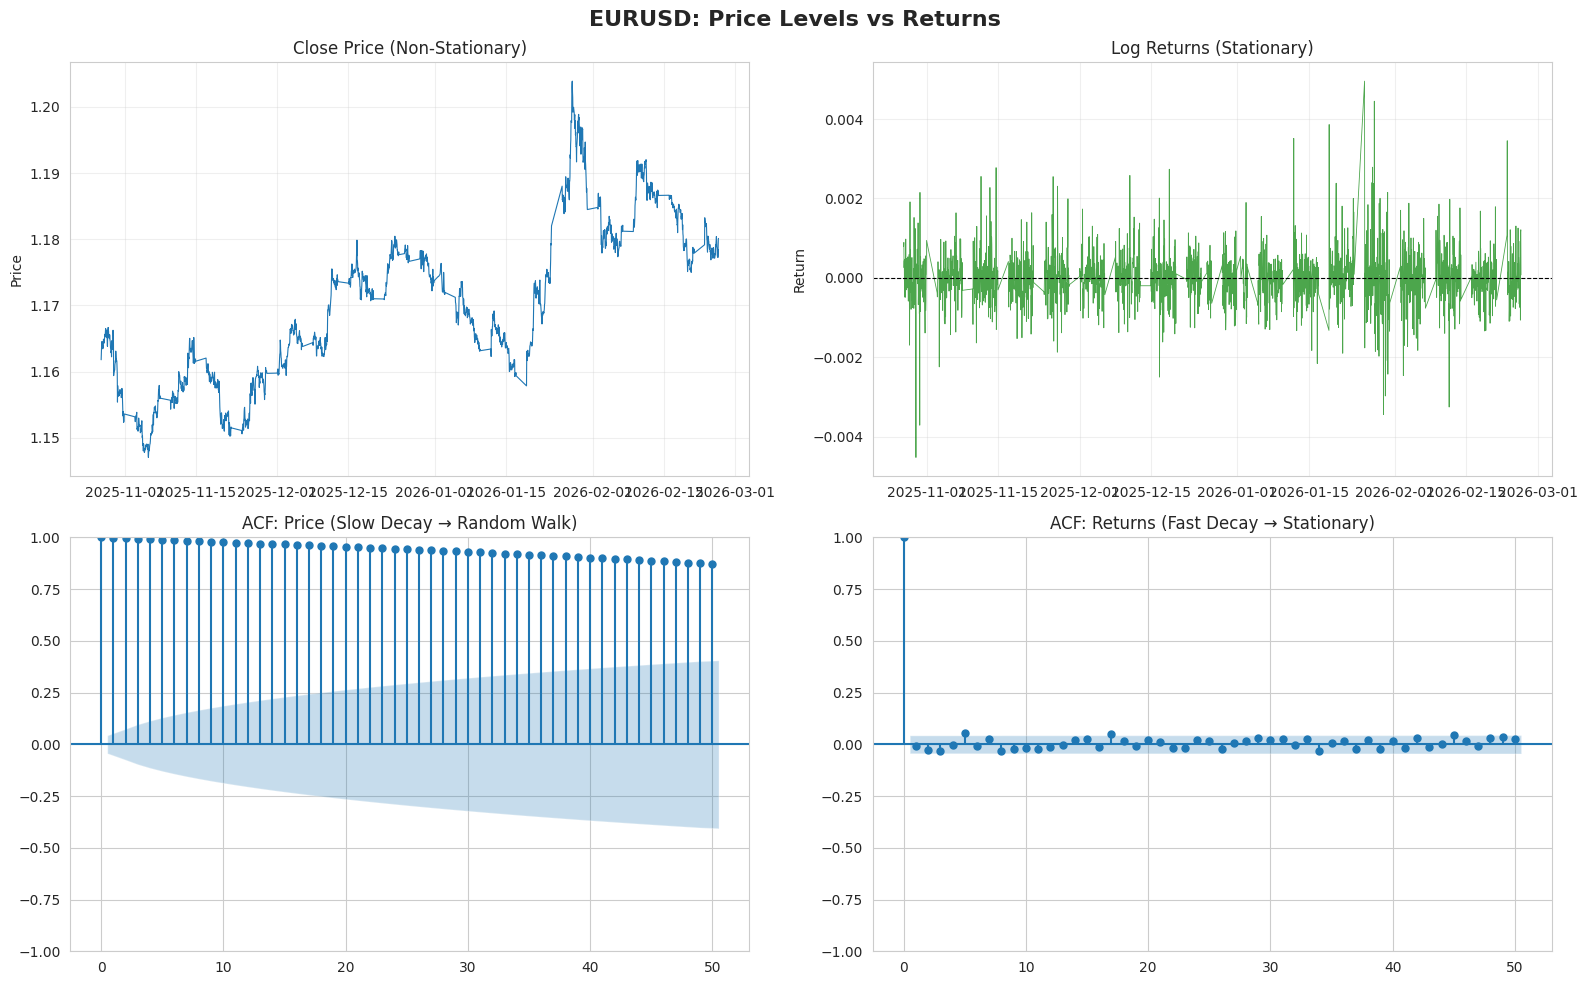

In [6]:
# Plot prices vs returns for EURUSD
pair = 'EURUSD'
df = data[pair]
returns = np.log(df['close'] / df['close'].shift(1))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{pair}: Price Levels vs Returns', fontsize=16, fontweight='bold')

# Price time series
axes[0, 0].plot(df.index, df['close'], linewidth=0.8)
axes[0, 0].set_title('Close Price (Non-Stationary)')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(True, alpha=0.3)

# Return time series  
axes[0, 1].plot(df.index, returns, linewidth=0.6, color='green', alpha=0.7)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Log Returns (Stationary)')
axes[0, 1].set_ylabel('Return')
axes[0, 1].grid(True, alpha=0.3)

# Price ACF
plot_acf(df['close'].dropna(), lags=50, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Price (Slow Decay → Random Walk)')

# Return ACF
plot_acf(returns.dropna(), lags=50, ax=axes[1, 1])
axes[1, 1].set_title('ACF: Returns (Fast Decay → Stationary)')

plt.tight_layout()
plt.show()

## Summary Table

In [6]:
# Create summary DataFrame
summary_data = []

for pair in data.keys():
    price_res = price_results[pair]
    return_res = return_results[pair]
    
    summary_data.append({
        'Pair': pair,
        'Price ADF p-val': f"{price_res['adf_pvalue']:.4f}",
        'Price Stationary': '✅' if price_res['is_stationary'] else '❌',
        'Return ADF p-val': f"{return_res['adf_pvalue']:.4f}",
        'Return Stationary': '✅' if return_res['is_stationary'] else '❌'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("STATIONARITY TEST SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


STATIONARITY TEST SUMMARY
  Pair Price ADF p-val Price Stationary Return ADF p-val Return Stationary
EURUSD          0.5336                ❌           0.0000                 ✅
GBPUSD          0.0633                ❌           0.0000                 ✅
USDJPY          0.1266                ❌           0.0000                 ✅


## Key Findings & Implications

### Expected Results:

1. **FX Prices are NON-STATIONARY** ❌
   - Random walk behavior
   - Mean/variance shift over time
   - ACF shows slow decay
   - **Cannot use for statistical modeling**

2. **FX Returns are STATIONARY** ✅
   - Mean-reverting
   - Constant variance (approximately)
   - ACF shows fast decay
   - **Suitable for trading strategies**

### Design Implications:

```python
# ❌ DO NOT DO THIS
signal = (price > sma_200).astype(int)

# ✅ DO THIS INSTEAD  
returns = np.log(price / price.shift(1))
signal = (returns > threshold).astype(int)
```

### Next Steps:
1. Always work with returns, not prices
2. Test autocorrelation in returns (Day 6)
3. Check for ARCH effects (volatility clustering)
4. Design strategies on return distributions

In [7]:
# Save results to report
report_dir = project_root / 'reports'
report_dir.mkdir(exist_ok=True)

report_path = report_dir / 'stationarity_analysis.md'

with open(report_path, 'w') as f:
    f.write("# Stationarity Analysis Report\n\n")
    f.write("## Executive Summary\n\n")
    f.write("**Finding:** FX prices exhibit unit root behavior (non-stationary), while returns are stationary.\n\n")
    f.write("**Implication:** Trading strategies must operate on returns, not raw price levels.\n\n")
    f.write("## Test Results\n\n")
    f.write(summary_df.to_markdown(index=False))
    f.write("\n\n## Methodology\n\n")
    f.write("- **ADF Test**: Tests for unit root (H0 = non-stationary)\n")
    f.write("- **KPSS Test**: Tests for stationarity (H0 = stationary)\n")
    f.write("- **Conclusion**: Series is stationary if both tests agree (ADF rejects, KPSS accepts)\n")

print(f"\n✅ Report saved to: {report_path}")


✅ Report saved to: /home/ghost/Workspace/Projects/Exhaustion-failure-to-continue-hypothesis/fx-quant-research/reports/stationarity_analysis.md
